In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl");

[ Info: Oceananigans will use 4 threads


In [2]:
function avg_between(file, field, z1, z2)
    k1, k2 = zᶜbounds(file, z1, z2)
    iterations, times = iterations_times(file)

    surface_mean(field) = mean(field[:, k1:k2]; dims=2)[:, 1]
    b_surface = timeseries_of(surface_mean, file, field, iterations)

    return b_surface
end

avg_between (generic function with 1 method)

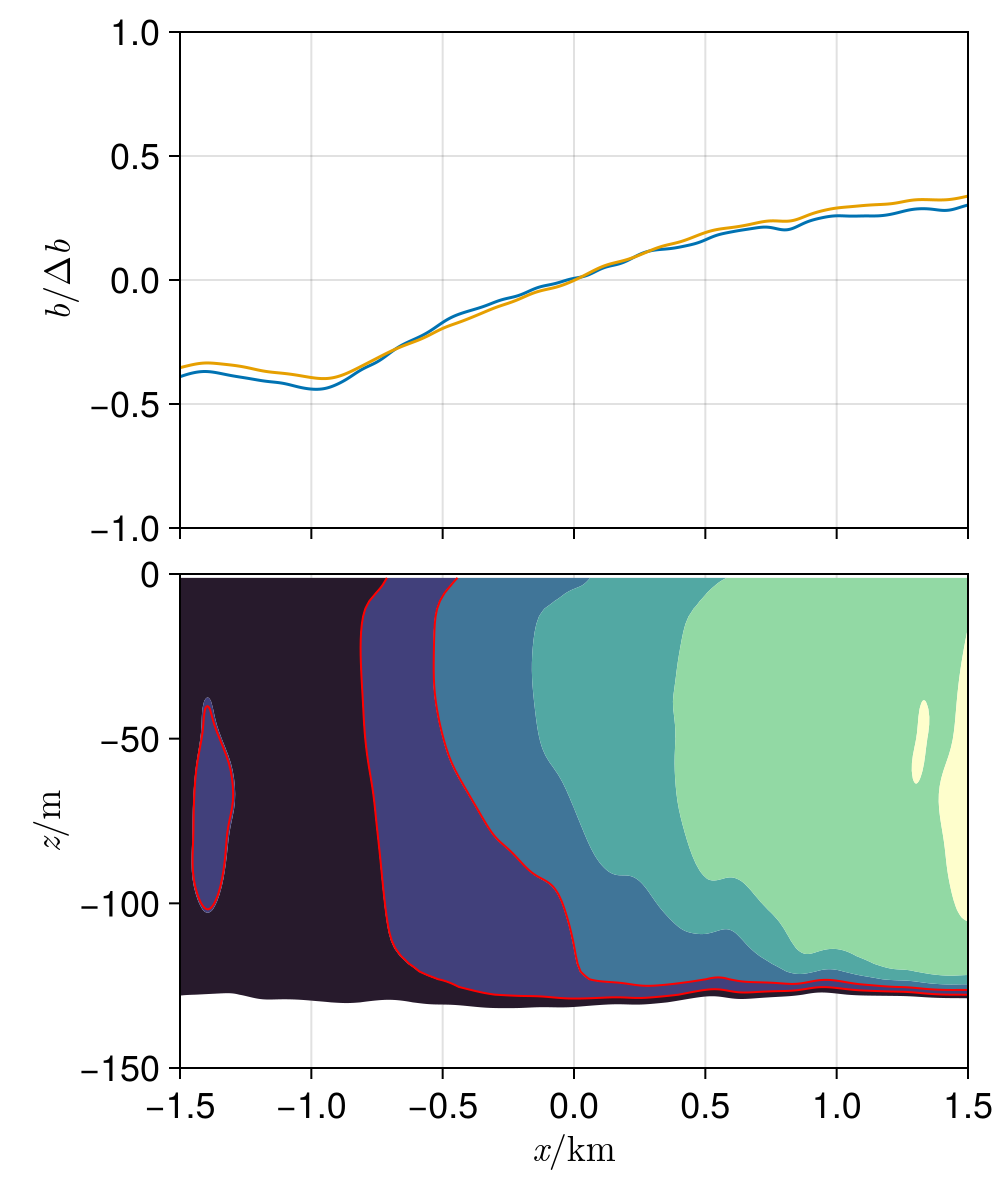

In [3]:
i = 14

run_ids = cooling_only.filenames
run_id = run_ids[i]

fig = Figure(; 
    size = (500, 600),
    fontsize = 18,
)
ax = Axis(fig[2, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-1.5, 1.5, -150, 0)
)

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
COARSE = joinpath(foldername, "COARSE.jld2")
iterations, times = iterations_times(COARSE)
sp = simulation_parameters(COARSE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
k1, k2 = zᶜbounds(COARSE, -sp.H, -5)

b = get_field(COARSE, "b_coarse", iterations[end]) do field
    filt(field, 0, 1) ./ sp.Δb
end
b = b .- mean(b[:, k1:k2])
bl = -2/6
br = bl + 1/6


contourf!(ax, xsᶜ ./ 1000, zsᶜ, b, levels=-0.5:0.166:0.5, colormap=reverse(to_colormap(:deep)))
contour!(ax, xsᶜ ./ 1000, zsᶜ, b, levels=[bl, br], color=:red)

ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"b/\Delta b",
    limits = (-1.5, 1.5, -1, 1),
    yticks = [-1, -0.5, 0, 0.5, 1]
)
hidexdecorations!(ax; ticks=false, grid=false)
b_integrated = mean(b[:, k1:k2]; dims=2)[:, 1]
b_surface = b[:, k2]

lines!(ax, xsᶜ ./ 1000, b_surface)
lines!(ax, xsᶜ ./ 1000, b_integrated)

fig

In [4]:
avg_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    bl = -2sp.Δb/6
    br = bl + sp.Δb/6
    ilr, xlr, ℓ = front_width(COARSE, "b_coarse", iterations, -sp.H, -5, bl, br)
    ℓ
end
surface_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    bl = -2sp.Δb/6
    br = bl + sp.Δb/6
    ilr, xlr, ℓ = front_width(COARSE, "b_coarse", iterations, -10, -5, bl, br)
    ℓ
end;

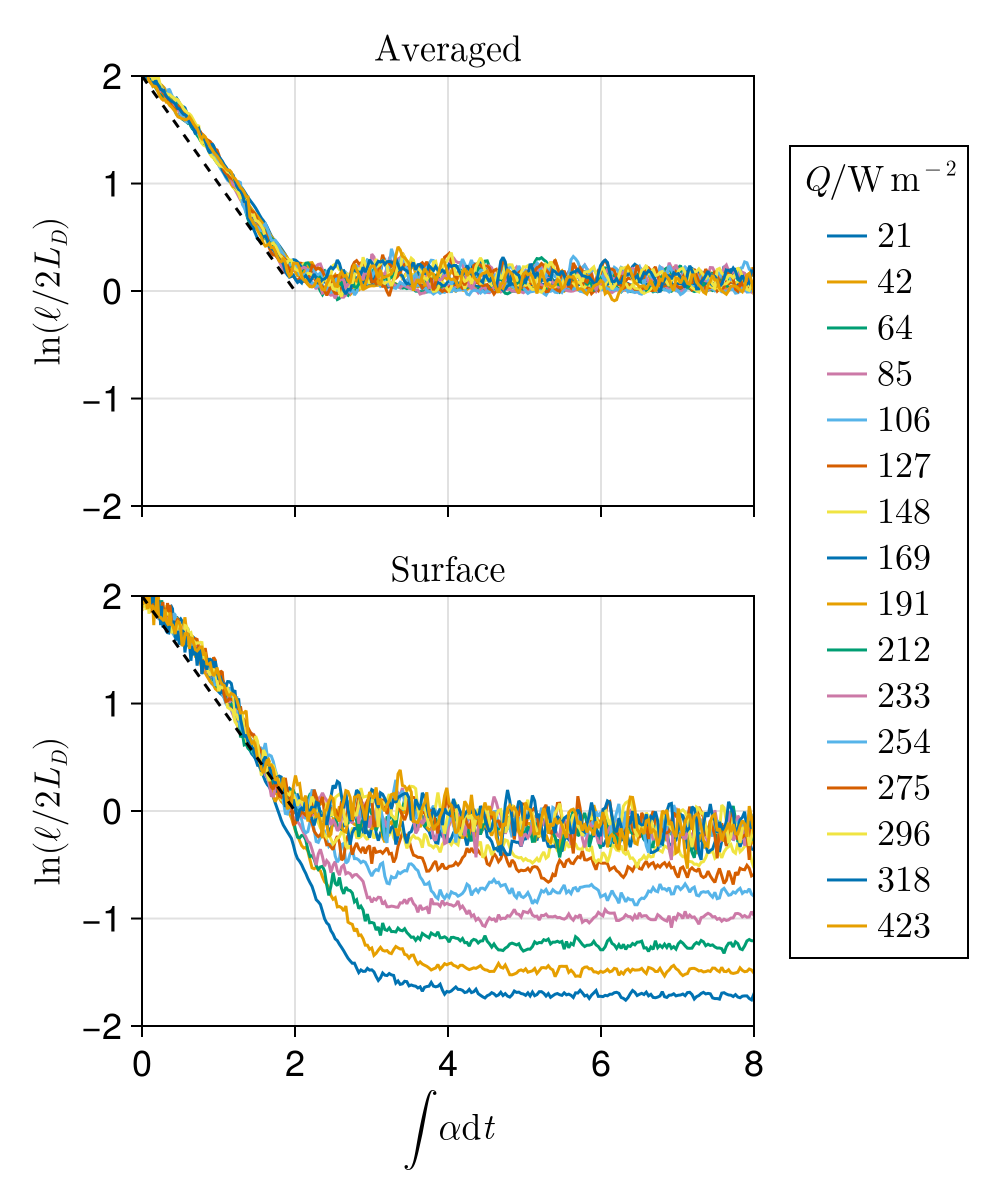

In [5]:
fig = Figure(; size=(500, 600), fontsize=18)
ax_avg = Axis(fig[1, 1];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Averaged}",
    limits = (0, 8, -2, 2)
)
hidexdecorations!(ax_avg; ticks=false, grid=false)
ax_surface = Axis(fig[2, 1];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Surface}",
    limits = (0, 8, -2, 2)
)
lns = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    
    lines!(ax_avg, s, log.(6avg_ℓs[i] ./ 2sp.L))
    lines!(ax_surface, s, log.(6surface_ℓs[i] ./ 2sp.L))
end
Qs = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    Q_str = @sprintf "%.0f" sp.Q
    L"%$Q_str"
end
lines!(ax_surface, 0:2, x->2-x; color=:black, linestyle=:dash)
lines!(ax_avg, 0:2, x->2-x; color=:black, linestyle=:dash)
Legend(fig[1:2, 2], lns, Qs, L"Q / \text{W}\,\text{m}^{-2}")
fig

In [9]:
run_ids = cooling_depth_01.filenames

avg_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    bl = -2sp.Δb/6
    br = bl + sp.Δb/6
    ilr, xlr, ℓ = front_width(COARSE, "b_coarse", iterations, -sp.H, -5, bl, br)
    ℓ
end
surface_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    bl = -2sp.Δb/6
    br = bl + sp.Δb/6
    ilr, xlr, ℓ = front_width(COARSE, "b_coarse", iterations, -10, -5, bl, br)
    ℓ
end;

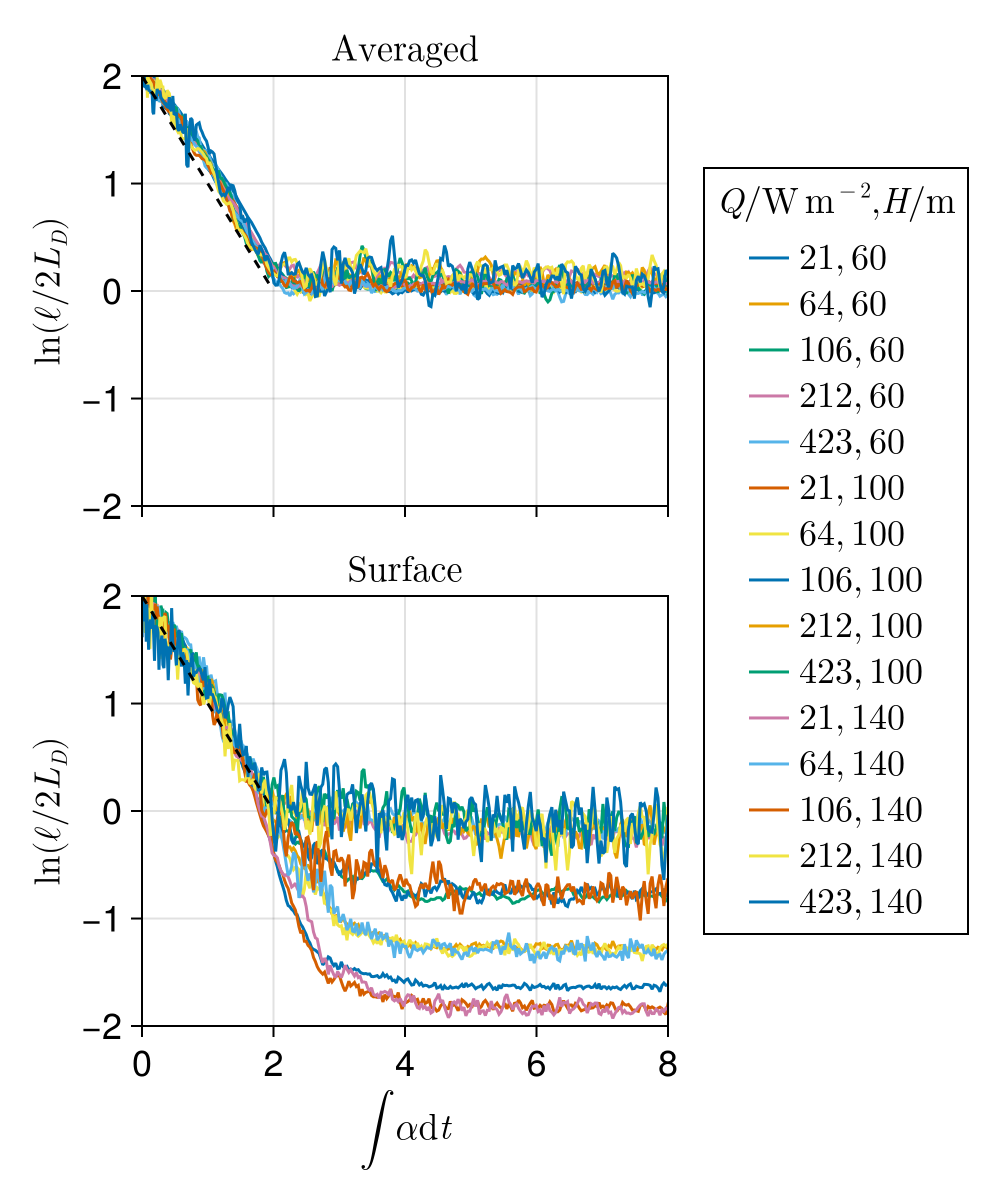

In [13]:
fig = Figure(; size=(500, 600), fontsize=18)
ax_avg = Axis(fig[1, 1];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Averaged}",
    limits = (0, 8, -2, 2)
)
hidexdecorations!(ax_avg; ticks=false, grid=false)
ax_surface = Axis(fig[2, 1];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Surface}",
    limits = (0, 8, -2, 2)
)

lns = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    
    lines!(ax_avg, s, log.(6avg_ℓs[i] ./ 2sp.L))
    lines!(ax_surface, s, log.(6surface_ℓs[i] ./ 2sp.L))
end
labels = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    Q_str = @sprintf "%.0f" sp.Q
    H_str = @sprintf "%.0f" sp.H
    L"%$Q_str, \, %$H_str"
end
lines!(ax_surface, 0:2, x->2-x; color=:black, linestyle=:dash)
lines!(ax_avg, 0:2, x->2-x; color=:black, linestyle=:dash)
Legend(fig[1:2, 2], lns, labels, L"Q / \text{W} \, \text{m}^{-2}, H / \text{m}")
fig

In [1]:
fig = Figure(; size=(800, 500))
ax_avg = Axis(fig[1, 1];
    xlabel = L"\beta_B",
    ylabel = L"\ell"
)
map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    
    scatter!(ax_avg, sp.βB, mean(6avg_ℓs[i][end-100:end] ./ 2sp.L)^2 * sp.H; marker=:+, color=i, colorrange=(1, 15))
    scatter!(ax_avg, sp.βB, mean(6surface_ℓs[i][end-100:end] ./ 2sp.L)^2 * sp.H; color=i, colorrange=(1, 15))
end
fig

LoadError: UndefVarError: `Figure` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Averaging over the mixed layer

In [ ]:
function ML_mask_profile(z, h, Δz)
    normalize = Δz * log(1 + exp(h / Δz))
    return 1 / (1 + exp(-(z+h)/Δz)) /  normalize
end

function ML_average!(res, field, h, zs, Δz)
    for i in 1:size(field, 1)
        z = zs[k]
        ML_mask = ML_mask_profile.(zs, h, Δz)
        res[i] .= sum(field[i, :] .* ML_mask) / sum(ML_mask)
    end
    return nothing
end

function ML_average(field, h, zs, Δz)
    res = zeroes(eltype(field), size(field, 1))
    ML_average!(res, field, h, zs, Δz)
    return res
end

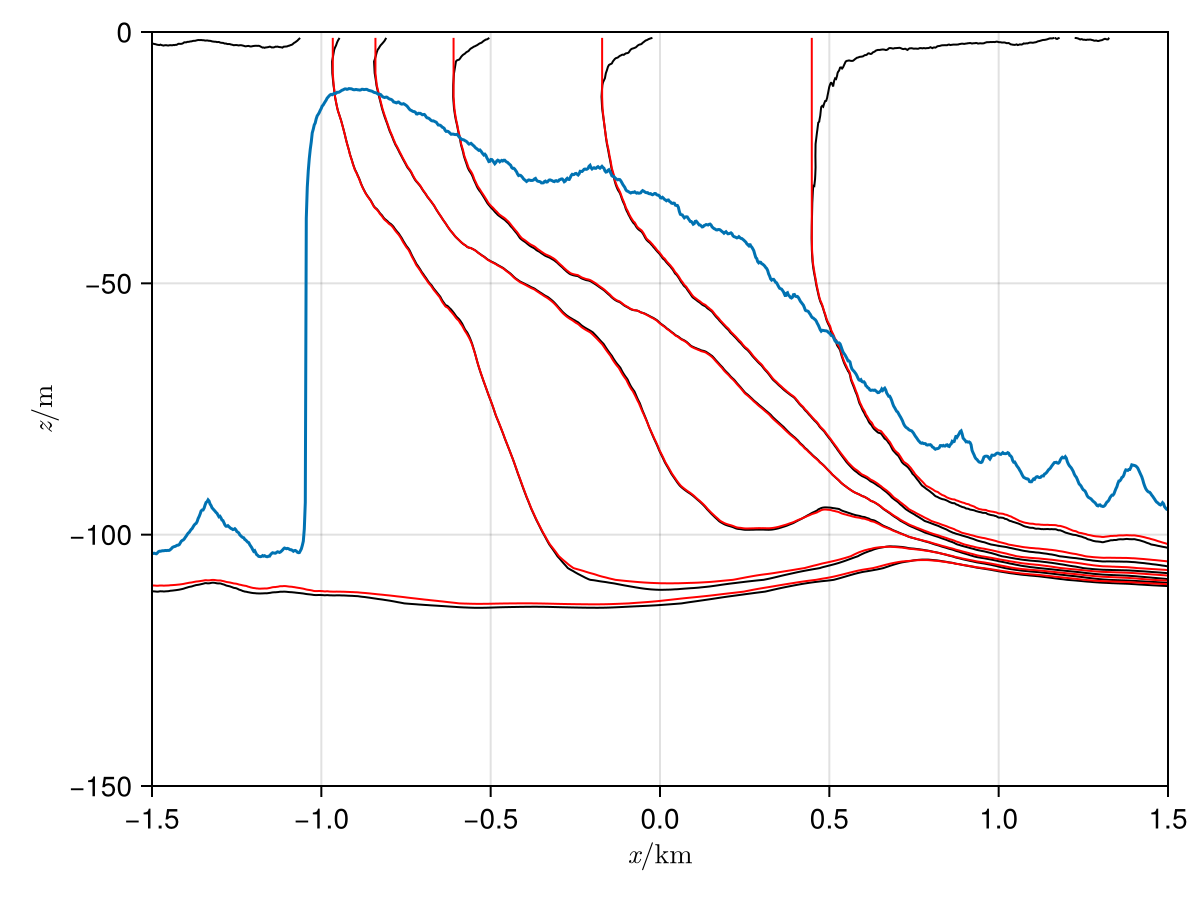

In [24]:
# Estimating mixed layer depth
function no_mixing_layer!(res, field)
    a = filt(field, 0, 1)
    res[:, 1] .= a[:, 1]
    res[:, 2:end] .= map(b->max(b, 0), diff(a; dims=2))
    cumsum!(res, res; dims=2)
    return nothing
end

function no_mixing_layer(field)
    res = zeros(eltype(field), size(field))
    no_mixing_layer!(res, field)
    return res
end

# We use a dynamical definition of the mixed layer
# It's the depth h required for the time derivative and ML
# average to commute on buoyancy

function mixed_layer_z(field, zs; abstol=0.01)
    field = no_mixing_layer(field)
    map(1:size(field, 1)) do i
        topval = field[i, end]
        interpolate(topval - abstol, field[i, :], zs)
    end
end

function front_error(field)
    field = field .- field[:, end:end]
    
    map(1:size(field, 2)) do k
        sqrt(mean(mean(field[:, k:end]; dims=2)).^2)
    end
end

function bulk_mixed_layer_z(field, zs; abstol=0.01)
    field = no_mixing_layer(field)
    interpolate(-abstol, -front_error(field), zs)
end

no_mixing_b = no_mixing_layer(b);
h = mixed_layer_z(b, zsᶜ)

fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)

contour!(ax, xsᶜ ./ 1000, zsᶜ, b; color=:black, levels=-0.5:0.166:0.5)
contour!(ax, xsᶜ ./ 1000, zsᶜ, no_mixing_b; color=:red, levels=-0.5:0.166:0.5)
lines!(ax, xsᶜ ./ 1000, h)
fig

In [25]:
hs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    
    mlz = timeseries_of(COARSE, "b_coarse", iterations) do field
        bulk_mixed_layer_z(field[inds, :] ./ sp.Δb, zsᶜ)
    end
end;

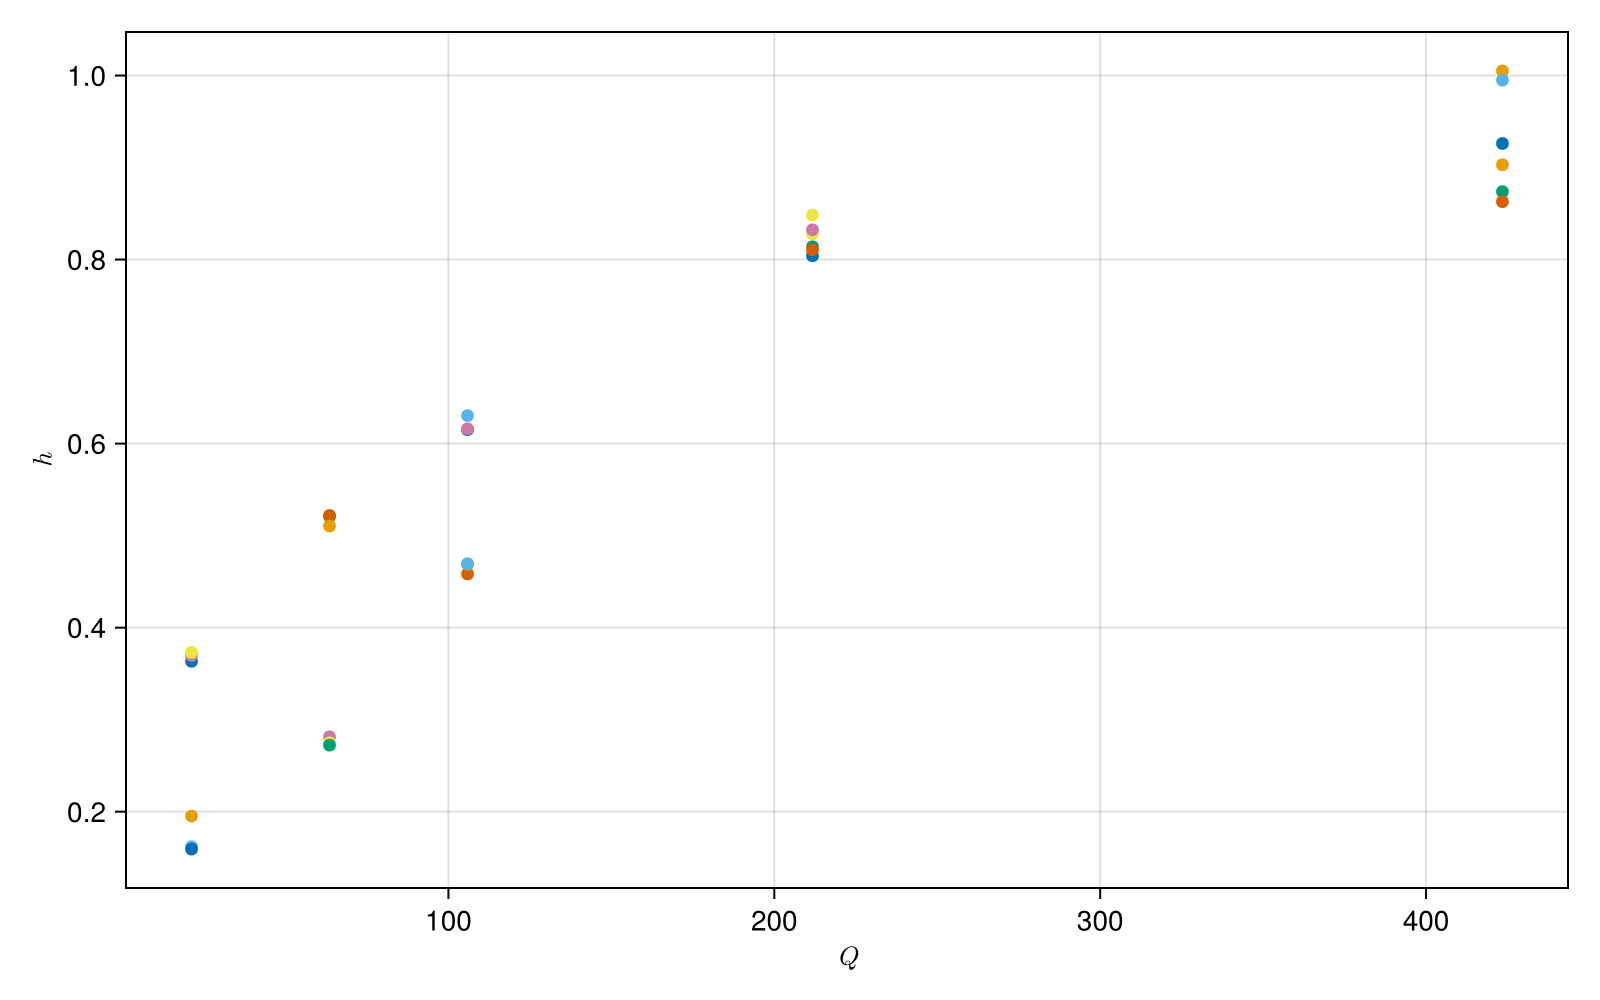

In [26]:
fig = Figure(; size=(800, 500))
ax_avg = Axis(fig[1, 1];
    xlabel = L"Q",
    ylabel = L"h"
)
map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    
    scatter!(ax_avg, sp.Q, sqrt(abs(mean(hs[i][end-100:end])) / sp.H))
    scatter!(ax_avg, sp.Q, 6 * mean(surface_ℓs[i][end-100:end]) / 2sp.L)
end
fig